# **1. LSTM**

LSTM(Long Short-Term Memory)은 RNN의 장기 의존성 문제를 해결하기 위해 고안된 모델입니다. 
<br>LSTM은 셀 상태(cell state)와 3개의 게이트(입력 게이트, 출력 게이트, 망각 게이트)를 사용하여 
<br>중요한 정보를 오랫동안 저장하고 불필요한 정보를 제거하는 구조를 갖추고 있습니다. 
<br>망각 게이트는 이전 셀 상태에서 필요 없는 정보를 삭제하고, 입력 게이트는 새로운 정보를 저장하며, 
<br>출력 게이트는 최종 출력을 결정합니다. 이러한 구조 덕분에 LSTM은 장기 시퀀스를 다루는 
<br>자연어 처리, 음성 인식, 시계열 예측 등의 다양한 분야에서 효과적으로 사용됩니다. 
<br>하지만 구조가 복잡하여 계산량이 많고, 학습 시간이 오래 걸린다는 단점이 있습니다.

![RNN과  LSTM](./images/RNN과%20%20LSTM.png)

### RNN의 문제점
- 기본 RNN에는 주로 Hidden State(h) 하나가 기억 역할을 함
- RNN은 시간 순서대로 같은 가중치를 반복해서 사용

```
    x1 > RNN > h1 > RNN > h2 > RNN > h3 ... > ht
```
- 학습할 때는 마지막 오차를 과거 시점까지 거꾸로 전달
```
    0.5
    0.5 * 0.5 = 0.25
    0.5 * 0.5 *0.5 = 0.125
    ...
    0.5^20 = ?
```
- 멀리 갈수록 Gradient가 매우 작아짐. 그러면 오래전 입력이 현재 오차에 어떤 영향을 주었는지 가중치가 거의 학습하지 못함 > 기울기 소실
- 1보다 큰 값이 반복적으로 곱해지면 Gradient가 지나치게 커질 수 있음 > 기울기 폭주

> Gradient가 정확히 0이어야만 기울기 소실은 아님. 0에 매우 가까워져 학습에 실질적인 영향을 거의 주지 못하는 상태도 기울기 소실이라고 함

### LSTM의 핵심 구조
- LSTM 한 시점 t에는 아래와 같은 정보가 들어옴
    - x_t: 현재 시점 입력
    - h_(t-1): 이전 시점 Hidden State. 현재 시점에서 다음 시점과 출력 계산에 직접 사용되는 내부 표현
    - c_(t-1): 이전 시점 Cell State. 시간축을 따라 정보를 전달하는 주된 내부 상태. 중요한 정보가 여러 시점 동안 유지될 수 있는 경로

1. Forget Gate
- 과거 기억을 남김
- sigmoid 결과로 단순한 삭제/유지가 아니라 이전 Cell State의 각 성분을 다음 단계로 얼마나 전달할지를 나타내는 0~1 사이의 비율
```
현재 입력 x_t
                    가중치 W_f와 계산 > b_f > sigmoid > f_t
이전 상태 h_(t-1)
처음에는 W_f, b_f가 적절한 값을 모름 > 학습 과정에서 예측 > 실제 정답과 비교 > Loss 계산 > 역전파 > W_f, b_f 수정 > 다음 Gate 출력도 달라짐(반복)
```
- 어떤 상황에서 이전 정보를 많이 통과시키는 것이 Loss를 줄이는지를 모델이 학습하게 됨
- Gate의 값은 사람이 만든 규칙이 아니라 학습된 가중치와 현재 입력/이전 상ㅌ태가 함께 만들어낸 결과

2. Input Gate
- 새 정보를 얼마나 저장할지
- 새로운 후보 기억도 만듦

3. Output Gate
- 출력으로 무엇을 보여줄지
```
    이전 Cell State > Forget Gate
                                    > 원소별 곱 > 새로운 Cell State(c_t) > Output Gate > Hidden State(h_t)
    현재 입력 > Input Gate
```

> Cell State의 갱신(과거 기억 + 새 기억)은 과거 기억 중 남길 부분에서 현재 입력에서 새로 저장할 부분을 더한 값

### 장기/단기 기억을 나누는 기준

```
현재 시점  t
    - 1시간 전 값
    - 2시간 전 값
    - 3시간 전 값
    - ...
    - 24시간 전 값
```
- LSTM 내부에 6시간보다 오래되면 장기 정보, 3시간 이내면 단기 정보와 같은 규칙은 없음
- 얼마나 오래된 정보인가보다 그 정보가 예측에 얼마나 도움이 되었는가가 중요
- 예) 전력 데이터에서 "매일 저녁 비슷한 시간에 사용량이 증가" 패턴이 반복된다면, 비교적 이전 시점에서 만들어진 정보라도 다음 값을 예측하는 데 유용할 수 있음 > 장기 정보
- 예) 1시간 전 정보라도 잡음에 가까워 예측에 도움이 되지 않는 성분은 > 단기 정보

> 사람이 장기/단기 정보를 미리 지정하는 모델이 아니라 학습을 통해 어떤 과거 정보의 영향력을 계속 유지하고, 어떤 정보의 영향력을 줄일지를 결정

데이터셋: https://archive.ics.uci.edu/dataset/235/individual%2Bhousehold%2Belectric%2Bpower%2Bconsumption

# **2. Household Electric Power Consumption 예제**
- 한 가정의 전력 사용량을 약 4년 동안 1분 간격으로 측정한 공개 시계열 데이터(약 207만 개의 관측치)
- Global_active_power 한 개만 이용해 최근 24시간의 전력 사용량 > 다음 시간의 전력 사용량을 예측
    - 원본: 1분 간격 > 예제: 1시간 단위 평균으로 변환
    - 입력 x:  직전 24시간의 Global Active Power
    - 정답 y: 그 다음 1시간의 Global Active Power

In [1]:
import random
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

warnings.filterwarnings("ignore")

In [2]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif hasattr(torch, "xpu") and torch.xpu.is_available():
    DEVICE = torch.device("xpu")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)

DEVICE: cpu


In [4]:
DATA_PATH = "./data/household_power_consumption.txt"
df = pd.read_csv(DATA_PATH, sep = ";", na_values="?", low_memory=False)
print(df.shape)

(2075259, 9)


- `Date`: 날짜
- `Time`: 시간
- `Global_active_power`: 전체 유효전력(kW). 실제로 소비되어 일을 하는 전력
- `Global_reactive_power`: 무효전력(kW). 전기장/자기장 형성 등에 관여하며 직접적인 유효 작업으로 소비되지 않는 성분
- `Voltage`: 평균 전압(V)
- `Global_intensity`: 평균 전류 세기(A)
- `Sub_metering_1`: 주방 일부 기기의 에너지 사용량(Wh)
- `Sub_metering_2`: 세탁실 관련 기기의 에너지 사용량(Wh)
- `Sub_metering_3`: 전기 온수기 및 에어컨 관련 에너지 사용량(Wh)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB


In [7]:
df.isna().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [8]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [11]:
df['datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'], format = "%d/%m/%Y %H:%M:%S", errors = "coerce")  # errors = "coerce" 에러가 나면 null 값으로 만들어라

In [12]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [13]:
invalid_datetime = df['datetime'].isna().sum()
df = df.dropna(subset=['datetime'])
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [14]:
df = df.sort_values("datetime")
df = df.set_index("datetime")
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [15]:
power = df[['Global_active_power']].copy()
power['Global_active_power'] = pd.to_numeric(power["Global_active_power"], errors='coerce')
power = power.dropna()
print(power.shape)

(2049280, 1)


In [ ]:
hourly = power.resample("1h").mean()
# hourly

missing_hours = hourly["Global_active_power"].isna().sum()
# missing_hours

print("시간 단위 결측 개수: ", missing_hours)

# 시계열 간격을 1시간으로 유지하기 위해 "과거의 마지막 관측값"으로 채움(이전 데이터를 다음 결측치에 채움)
# SEQ_LENGTH=24를 정말 24시간이라고 부르려면 데이터 간격이 일정해야 함
hourly = hourly.ffill().dropna()
print("hourly shape: ", hourly.shape)

시간 단위 결측 개수:  421
hourly shape:  (34589, 1)


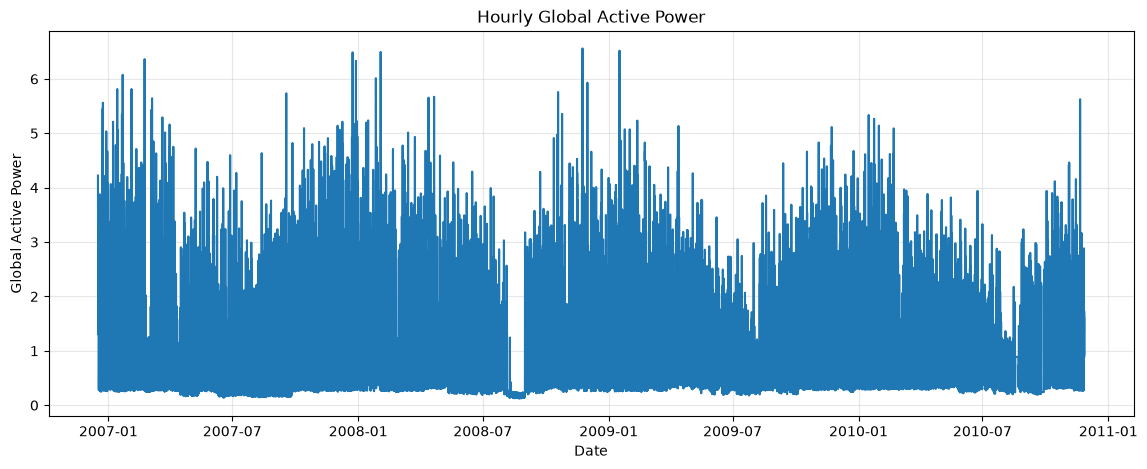

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(hourly.index, hourly["Global_active_power"])
plt.title("Hourly Global Active Power")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.grid(alpha=0.3)
plt.show()

In [23]:
values = hourly['Global_active_power'].values.reshape(-1, 1)

In [24]:
n = len(values)
n

34589

In [25]:
train_end = int(n * 0.70)
val_end = int(n * 0.85)
print("전체: ", n)
print("Train: ", train_end)
print("Val: ", val_end - train_end)
print("Test: ", n - val_end)

전체:  34589
Train:  24212
Val:  5188
Test:  5189


In [28]:
scaler = StandardScaler()
scaler.fit(values[:train_end])
scaled_values = scaler.transform(values).astype(np.float32)
scaled_values

array([[ 3.3853934 ],
       [ 2.7481422 ],
       [ 2.4978902 ],
       ...,
       [ 0.61976004],
       [ 0.08505737],
       [-0.16203   ]], shape=(34589, 1), dtype=float32)

In [29]:
SEQ_LENGTH = 24 

def make_sequence(data, seq_length):
    X = []
    y = []
    target_indices = []

    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length: i]) # i - 24 ~ i - 1
        y.append(data[i])   # i 시점 (바로 다음 1시간)
        target_indices.append(i)

    return(np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(target_indices))

In [31]:
X, y, indices = make_sequence(scaled_values, SEQ_LENGTH)
print(X.shape) # (34565, 24, 1)
print(y.shape) # (34565 , 1)

print("첫 번째 X가 사용하는 원본 시간: ", hourly.index[0], "~", hourly.index[SEQ_LENGTH - 1])
print("첫 번째 y가 사용하는 원본 시간: ", hourly.index[SEQ_LENGTH])

(34565, 24, 1)
(34565, 1)
첫 번째 X가 사용하는 원본 시간:  2006-12-16 17:00:00 ~ 2006-12-17 16:00:00
첫 번째 y가 사용하는 원본 시간:  2006-12-17 17:00:00


In [32]:
train_mask = indices < train_end
val_mask = (indices >= train_end) & (indices < val_end)
test_mask = indices >= val_end

print("Train sequences:", train_mask.sum())
print("Val sequences:", val_mask.sum())
print("Test sequences:", test_mask.sum())

Train sequences: 24188
Val sequences: 5188
Test sequences: 5189


In [33]:
X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print('Train: ', X_train.shape, y_train.shape)
print('Val: ', X_val.shape, y_val.shape)
print('Test: ', X_test.shape, y_test.shape)

Train:  (24188, 24, 1) (24188, 1)
Val:  (5188, 24, 1) (5188, 1)
Test:  (5189, 24, 1) (5189, 1)


In [34]:
class PowerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [35]:
BATCH_SIZE = 64

train_loader = DataLoader(PowerDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(PowerDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(PowerDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

In [36]:
xb, yb = next(iter(train_loader))
print(xb.shape)
print(yb.shape)

torch.Size([64, 24, 1])
torch.Size([64, 1])


### LSTM의 입력과 출력
- batch_first = True일 때 입력 X의 shape는 (batch_size, sequence_length, input_size)
- 예) (64, 24, 1): batch에 64rodml sequence, 직전 24시간, 한 시간마다 feature 1개
- LSTM을 통과시키면 out, (h_n, c_n) = self.lstm(x)
    - out: 모든 시점의 마지막 LSTM Layer hidden State > (batch, seq_len, hidden_size)
    - h_n: 각 layer의 마지막 시점 hidden state > (num_layers, batch, hidden_size)
    - c_n: 각 layer의 마지막 시점 Cell state > (num_layers, batch, hidden_size)

> 당방향 LSTM에서 마지막 layer에 대해 마지막 hidden state는 out[:, -1, :]와 h_n[-1]

In [49]:
class PowerLSTM(nn.Module):
    def __init__(self, input_size = 1, hidden_size = 64, num_layers = 2, dropout = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size, num_layers = num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = out[:, -1, :]
        prediction = self.fc(last_hidden)
        return prediction

In [50]:
model = PowerLSTM().to(DEVICE)
model

PowerLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [51]:
model.eval()

with torch.no_grad():
    sample_x = xb[:4].to(DEVICE)
    out, (h_n, c_n) = model.lstm(sample_x)

print("입력: ", sample_x.shape)
print("out: ", out.shape)
print("h_n(hidden state): ", h_n.shape)
print("c_n: ", c_n.shape)  # 앞에 2가 레이어 2란 뜻

입력:  torch.Size([4, 24, 1])
out:  torch.Size([4, 24, 64])
h_n(hidden state):  torch.Size([2, 4, 64])
c_n:  torch.Size([2, 4, 64])


In [52]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-3, weight_decay = 1e-4)

MAX_EPOCHS = 50
PATIENCE = 8
CLIP_NORM = 1.0

In [53]:
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)

            batch_size = xb.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size

    return total_loss / total_count

In [54]:
best_val_loss = float("inf")
best_state = None
wait = 0

train_history = []
val_history = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_count = 0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_NORM)
        optimizer.step()
        batch_size = xb.size(0)
        train_loss_sum += (loss.item() * batch_size)
        train_count += batch_size
    train_loss = (train_loss_sum / train_count)
    val_loss = evaluate_loss(model, val_loader, criterion, DEVICE)
    train_history.append(train_loss)
    val_history.append(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    print(
        f"Epoch {epoch:02d} | "
        f"Train {train_loss:.6f} | "
        f"Valid {val_loss:.6f}"
    )

    if wait >= PATIENCE:
        print("Early Stopping")
        break

Epoch 01 | Train 0.528959 | Valid 0.435212
Epoch 02 | Train 0.436238 | Valid 0.406672
Epoch 03 | Train 0.424127 | Valid 0.389534
Epoch 04 | Train 0.416909 | Valid 0.384094
Epoch 05 | Train 0.413557 | Valid 0.383347
Epoch 06 | Train 0.410809 | Valid 0.384961
Epoch 07 | Train 0.407475 | Valid 0.377114
Epoch 08 | Train 0.403993 | Valid 0.384180
Epoch 09 | Train 0.404282 | Valid 0.377842
Epoch 10 | Train 0.400758 | Valid 0.373093
Epoch 11 | Train 0.400126 | Valid 0.390488
Epoch 12 | Train 0.400027 | Valid 0.371408
Epoch 13 | Train 0.397733 | Valid 0.392086
Epoch 14 | Train 0.396883 | Valid 0.375317
Epoch 15 | Train 0.394593 | Valid 0.371595
Epoch 16 | Train 0.391106 | Valid 0.377754
Epoch 17 | Train 0.391857 | Valid 0.368567
Epoch 18 | Train 0.389636 | Valid 0.374583
Epoch 19 | Train 0.389735 | Valid 0.371137
Epoch 20 | Train 0.387077 | Valid 0.369714
Epoch 21 | Train 0.384794 | Valid 0.374471
Epoch 22 | Train 0.383239 | Valid 0.369723
Epoch 23 | Train 0.382471 | Valid 0.374054
Epoch 24 | 

In [55]:
if best_state is not None:
    model.load_state_dict(best_state)

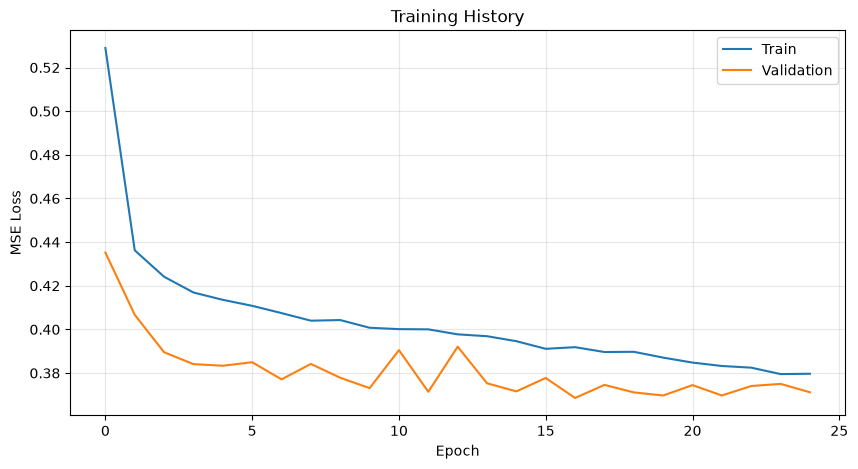

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(train_history, label="Train")
plt.plot(val_history, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [57]:
def predict(model, loader, device):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            preds.append(pred.cpu().numpy())
            trues.append(yb.cpu().numpy())
    return (np.vstack(preds), np.vstack(trues))

In [58]:
pred_scaled, true_scaled = predict(model, test_loader, DEVICE)
pred = scaler.inverse_transform(pred_scaled).ravel()
true = scaler.inverse_transform(true_scaled).ravel()

In [59]:
rmse = root_mean_squared_error(true, pred)
mae = mean_absolute_error(true, pred)
print(f"LSTM RMSE: {rmse:.4f}")
print(f"LSTM MAE : {mae:.4f}")

LSTM RMSE: 0.4833
LSTM MAE : 0.3311


In [62]:
last_input_scaled = X_test[:, -1, :]
baseline_pred = scaler.inverse_transform(last_input_scaled).ravel()

baseline_rmse = root_mean_squared_error(true, baseline_pred)
baseline_mae = mean_absolute_error(true, baseline_pred)

print(f'Persistence RMSE: {baseline_rmse:.4f}')
print(f'Persistence MAE: {baseline_mae:.4f}')
print(f'LSTM RMSE: {rmse:.4f}')
print(f'LSTM MAE: {mae:.4f}')

Persistence RMSE: 0.5759
Persistence MAE: 0.3729
LSTM RMSE: 0.4833
LSTM MAE: 0.3311


In [63]:
test_indices = indices[test_mask]
test_dates = hourly.index[test_indices]
N_VIEW = min(200, len(test_dates))

In [64]:
len(test_dates)

5189

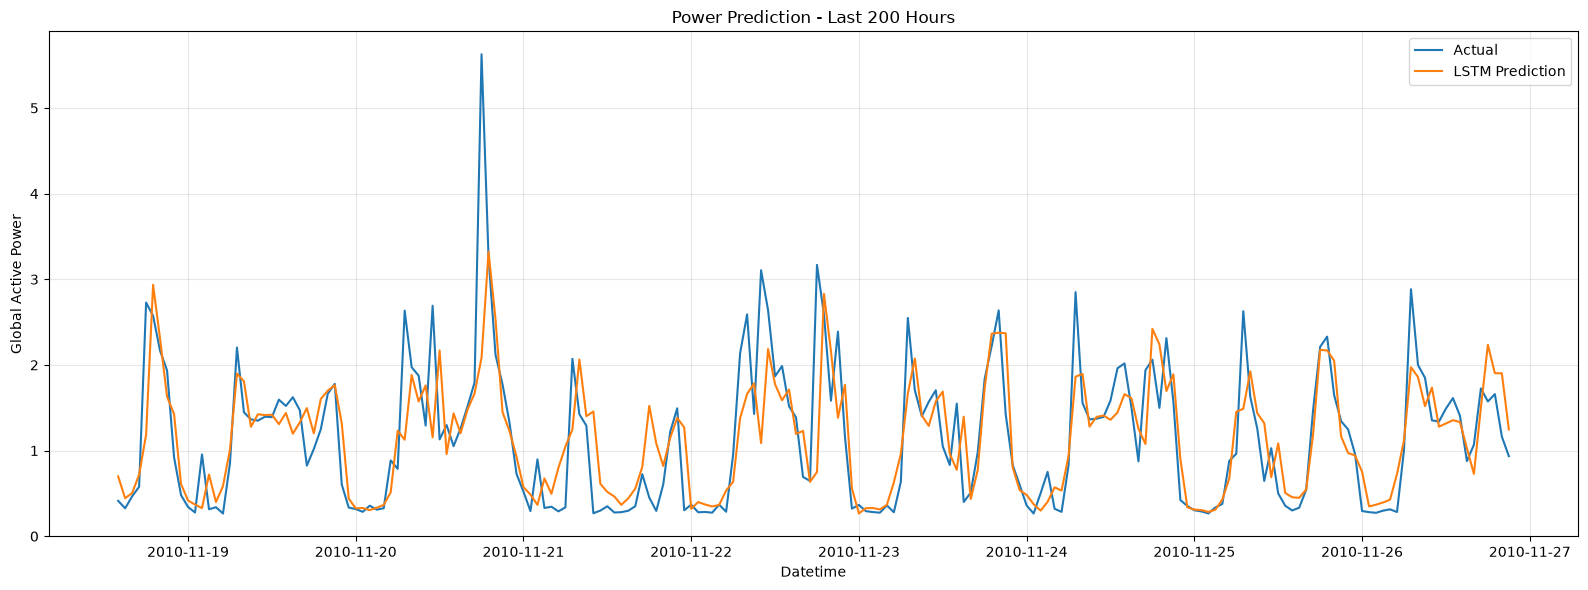

In [65]:
plt.figure(figsize=(16, 6))

plt.plot(
    test_dates[-N_VIEW:],
    true[-N_VIEW:],
    label="Actual"
)

plt.plot(
    test_dates[-N_VIEW:],
    pred[-N_VIEW:],
    label="LSTM Prediction"
)

plt.title(
    f"Power Prediction - Last {N_VIEW} Hours"
)

plt.xlabel("Datetime")
plt.ylabel("Global Active Power")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 그래프에서 확인할 것
1. 실제값의 상승/하락 방향을 어느정도 잘 따라가는지
2. 급격한 peak를 지나치게 평평하게 예측하진 않는지
3. 예측이 실제값보다 한 시점 늦게 따라가는 현상은 없는지

> 시계열 예측은 지표 하나 + 그래프 하나만으로 충분하지 않으며, baseline과 여러 구간의 오차를 함께 확인하는 방법이 중요

# **3. GRU**
GRU(Gated Recurrent Unit)는 2014년 뉴욕대학교(NYU) 조경현(Kyunghyun Cho) 교수 연구팀이 제안한 RNN의 장기 의존성 문제를 해결하기 위해 개발한 신경망 구조입니다. 
<br>LSTM과 유사한 성능을 가지면서도 더 간단한 구조를 갖고 있어 연산량이 적고 학습 속도가 빠릅니다. 
<br>GRU는 업데이트 게이트(Update Gate)와 리셋 게이트(Reset Gate)라는 두 개의 게이트만을 사용하여 정보를 조절하며, 
<br>LSTM보다 파라미터 수가 적어 적은 데이터셋에서도 효과적으로 학습할 수 있습니다. 
<br>업데이트 게이트는 이전 정보를 얼마나 유지할지 결정하고, 리셋 게이트는 새로운 정보를 반영하기 위해 기존 정보를 얼마나 잊을지 조정합니다. 
<br>이러한 특성 덕분에 GRU는 텍스트 처리, 음성 인식, 시계열 예측 등에서 LSTM보다 더 빠르고 효율적으로 사용할 수 있지만, 
<br>장기 의존성이 중요한 경우 LSTM이 더 나은 성능을 보일 수도 있습니다.


![GRU](./images/GRU.png)


모듈 생성 방식은 동일
```
LSTM
lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first = True)
out, (h_n, c_n) = lstm(x)

GRU
gru = nn.GRU(input_size, hidden_size, num_layers, batch_first = True)
out, h_n = gru(x)
```

> GRU는 별도의 Cell State가 없으므로 hidden state만 반환